In [1]:
from Configurations.imports import *

In [7]:
# Load the iris dataset
from sklearn.datasets import load_iris
iris = load_iris()

### We need to predict which type of flower we have

In [10]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [17]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

In [19]:
# split the data into train and test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=43)

In [21]:
from sklearn.tree import DecisionTreeClassifier
classifier =  DecisionTreeClassifier()

### Important Decision Tree Parameters

#### 1. `max_depth`

**What it controls:**
Maximum depth of the tree.

Example:

```python
max_depth = 5
```

Meaning:
The tree cannot grow deeper than **5 levels**.

Why important:

* Large depth → tree memorizes data → **overfitting**
* Small depth → tree too simple → **underfitting**

So this parameter directly controls **model complexity**.

---

#### 2. `min_samples_split`

**What it controls:**
Minimum number of samples required to split a node.

Example:

```python
min_samples_split = 10
```

Meaning:

If a node has **less than 10 samples**, it **cannot split further**.

Why important:

This prevents the tree from creating **too many small branches**, which causes overfitting.

---

#### 3. `min_samples_leaf`

**What it controls:**
Minimum number of samples allowed in a **leaf node**.

Example:

```python
min_samples_leaf = 5
```

Meaning:

Every leaf must contain **at least 5 samples**.

Why important:

Stops the tree from creating **leaf nodes with only 1 sample**, which usually represent **noise**.

This is one of the **best ways to reduce overfitting**.

---

#### 4. `max_features`

**What it controls:**
How many features are considered when choosing a split.

Example:

```python
max_features = "sqrt"
```

Meaning:

The algorithm randomly chooses **√(number of features)** to evaluate.

Why useful:

* introduces randomness
* reduces overfitting

This idea is heavily used in Random Forest.

---

#### 5. `ccp_alpha`

**What it controls:**
Pruning strength.

Example:

```python
ccp_alpha = 0.01
```

Meaning:

Higher value → **more pruning** → **smaller tree**

Why important:

Helps remove **unnecessary branches** that cause overfitting.

---

# Quick Summary

| Parameter         | What it does                      |
| ----------------- | --------------------------------- |
| max_depth         | limits tree depth                 |
| min_samples_split | minimum samples needed to split   |
| min_samples_leaf  | minimum samples allowed in leaf   |
| max_features      | number of features used for split |
| ccp_alpha         | pruning strength                  |

---


In [22]:
classifier.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.662\nsamples = 100\nvalue = [35.0, 28.0, 37.0]'),
 Text(0.3, 0.75, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'x[3] <= 1.65\ngini = 0.49\nsamples = 65\nvalue = [0, 28, 37]'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.18\nsamples = 30\nvalue = [0, 27, 3]'),
 Text(0.1, 0.4166666666666667, 'gini = 0.0\nsamples = 26\nvalue = [0, 26, 0]'),
 Text(0.3, 0.4166666666666667, 'x[0] <= 6.15\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.25, 'x[3] <= 1.55\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.1, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.3, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.8, 0.5833333333333334, 'x[2] <= 4.85\ngini = 0.056\nsamples = 35\nvalue = [0, 1, 34]

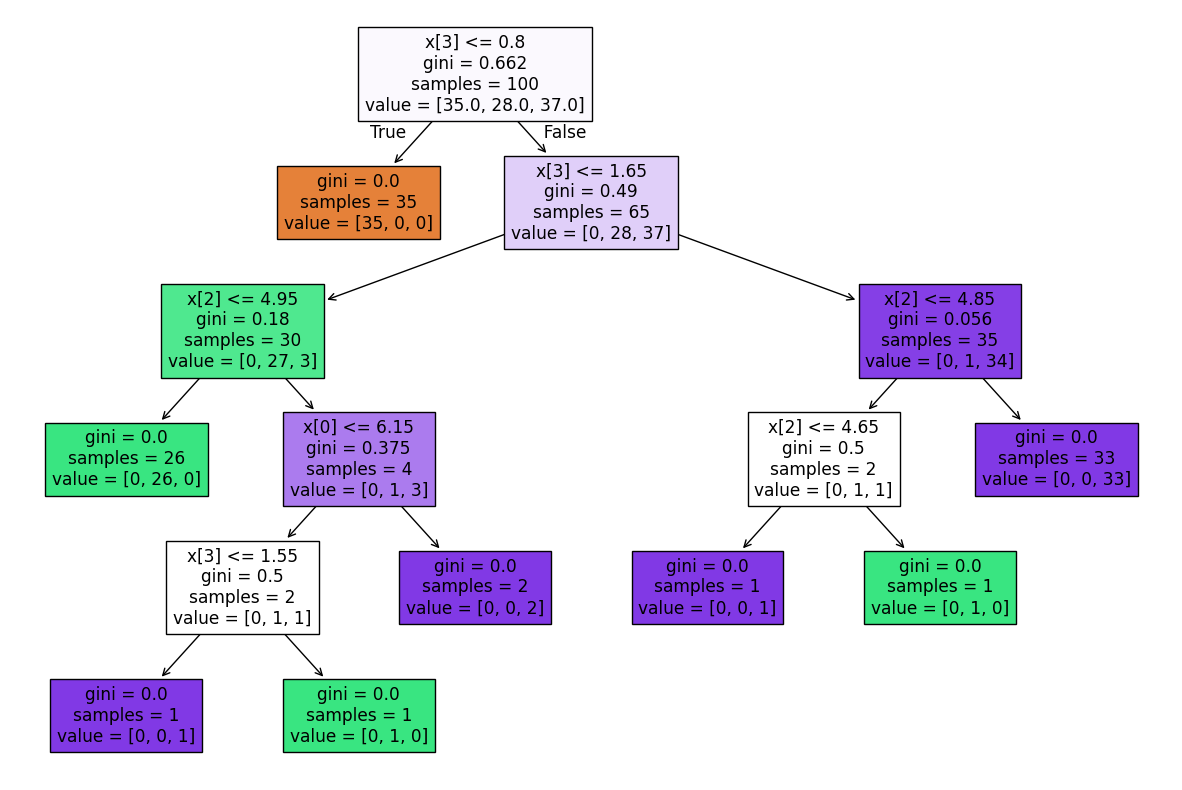

In [24]:
# visualising the tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(classifier, filled=True)



#### How to Read One Node

Look at the root node:

```
x[3] <= 0.8
gini = 0.662
samples = 100
value = [35, 28, 37]
```

#### 1️ `x[3] <= 0.8`

This is the **split condition**.

`x[3]` means **feature index 3** from the iris dataset.

Feature mapping:

```
x[0] → sepal length
x[1] → sepal width
x[2] → petal length
x[3] → petal width
```

So the split is:

```
petal width <= 0.8
```

---

#### 2️ `gini`

This is the **Gini impurity** of the node.

```
gini = 0
```

means **pure node** (only one class).

Root:

```
gini = 0.662
```

means classes are **mixed**.

---

#### 3️ `samples`

```
samples = 100
```

Number of training samples that **reached this node**.

---

#### 4️ `value`

```
value = [35, 28, 37]
```

Number of samples from each class.

For iris:

```
[setosa, versicolor, virginica]
```

So here:

```
35 setosa
28 versicolor
37 virginica
```

Prediction = **class with highest count**.

---


#### Color Meaning

Colors represent **predicted class**:

* 🟧 orange → setosa
* 🟩 green → versicolor
* 🟪 purple → virginica

Darker color = **more pure node**.

---


In [26]:
y_pred = classifier.predict(x_test)

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.91      0.95      0.93        22
           2       0.92      0.85      0.88        13

    accuracy                           0.94        50
   macro avg       0.94      0.93      0.94        50
weighted avg       0.94      0.94      0.94        50

